# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mayurkharche01/Internship-starter-flyrank/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

I chose **Random Forest classification** for this lane.

The goal is to rank content items that may deserve review, so a model that can capture non-linear relationships between signals such as visibility, freshness, position, engagement, and content characteristics is useful.

Random Forest is appropriate because:

* it can model non-linear relationships;
* it can work with mixed numeric and categorical features after preprocessing;
* it is less dependent on linear assumptions than logistic regression;
* it provides a useful decision-support ranking through predicted probabilities;
* feature importance can be investigated using permutation importance.

I am not choosing the most complex model automatically. The model will only be considered useful if it improves the baseline on the same evaluation data and metric.

The target is the starter proxy label:

`is_declining_label = trend_direction == "down"`

This is a current-window proxy rather than a future causal outcome, so results are interpreted as directional decision-support evidence rather than proof that a refresh will cause recovery.


In [1]:
# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.inspection import permutation_importance

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Possible locations for the anonymized starter dataset
possible_paths = [
    "../data/raw/content_refresh_anonymized.csv",
    "../../data/raw/content_refresh_anonymized.csv",
    "data/raw/content_refresh_anonymized.csv",
    "/content/data/raw/content_refresh_anonymized.csv",
    "/content/content_refresh_anonymized.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Expected content_refresh_anonymized.csv "
        "inside data/raw/."
    )

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Path:", data_path)
print("Shape:", df.shape)

Dataset loaded successfully.
Path: ../../data/raw/content_refresh_anonymized.csv
Shape: (30000, 44)


In [3]:
# Make a working copy
data = df.copy()

# Remove duplicate content items when content_id exists
if "content_id" in data.columns:
    data = data.drop_duplicates(subset="content_id")

# Apply starter data-quality conditions when columns exist
if "impressions_90d" in data.columns:
    data = data[data["impressions_90d"] > 0]

if "content_age_days" in data.columns:
    data = data[data["content_age_days"] >= 90]

data = data.reset_index(drop=True)

print("Prepared dataset shape:", data.shape)

Prepared dataset shape: (30000, 44)


In [4]:
# Create the binary target
if "trend_direction" not in data.columns:
    raise KeyError("trend_direction column was not found.")

data["is_declining_label"] = (
    data["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Target distribution:")
display(
    data["is_declining_label"]
    .value_counts()
    .rename(index={0: "Not declining", 1: "Declining"})
)

print("\nTarget rate:")
print(round(data["is_declining_label"].mean(), 4))

Target distribution:


is_declining_label
Declining        16262
Not declining    13738
Name: count, dtype: int64


Target rate:
0.5421


In [5]:
# Columns that should not be used as model features
excluded_columns = [
    "is_declining_label",
    "trend_direction",
    "content_id",
    "client_id"
]

# Exclude any obvious target/product decision fields if they exist
risk_keywords = [
    "label",
    "target",
    "priority_score",
    "health_score",
    "action_type",
    "refresh_flag",
    "decision_flag"
]

risk_columns = []

for col in data.columns:
    col_lower = col.lower()

    if col in excluded_columns:
        continue

    if any(keyword in col_lower for keyword in risk_keywords):
        risk_columns.append(col)

print("Potential leakage / decision-output columns:")
print(risk_columns)

Potential leakage / decision-output columns:
[]


## 2. Split design

I use a **client-group holdout split**.

The same client can have multiple content items, so randomly splitting individual rows could place pages from the same client in both training and test data. That could make the test result look better because the model may learn client-specific patterns.

Instead, complete clients are assigned to either the training or test set.

This means the model is evaluated on clients that were not used during training.

I use an 80/20 group split with a fixed random seed so that the experiment is reproducible.

This is an honest validation design for this dataset because the unit being ranked is a content item, while multiple content items can belong to the same client.


In [6]:
# Confirm client_id exists
if "client_id" not in data.columns:
    raise KeyError(
        "client_id is required for client-group validation."
    )

X_all = data.drop(columns=["is_declining_label"])
y_all = data["is_declining_label"]

groups = data["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_all, y_all, groups=groups)
)

train_data = data.iloc[train_idx].copy()
test_data = data.iloc[test_idx].copy()

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("\nTraining clients:", train_data["client_id"].nunique())
print("Testing clients:", test_data["client_id"].nunique())

Training rows: 23837
Testing rows: 6163

Training clients: 25
Testing clients: 7


In [7]:
train_clients = set(train_data["client_id"].unique())
test_clients = set(test_data["client_id"].unique())

overlap = train_clients.intersection(test_clients)

print("Number of overlapping clients:", len(overlap))

if len(overlap) == 0:
    print("PASS: No client appears in both train and test.")
else:
    print("WARNING: Client overlap detected.")

Number of overlapping clients: 0
PASS: No client appears in both train and test.


In [8]:
print("Training target rate:")
print(round(train_data["is_declining_label"].mean(), 4))

print("\nTesting target rate:")
print(round(test_data["is_declining_label"].mean(), 4))

Training target rate:
0.5501

Testing target rate:
0.511


## 3. Train + compare vs my baseline

I compare the Random Forest against the transparent baseline on the **same test set**.

The baseline is based on observable signals rather than a learned model. The starter baseline combines:

* visibility;
* freshness risk;
* position opportunity;
* content depth gap.

The baseline formula is:

`0.40 × visibility_score + 0.30 × freshness_risk_score + 0.25 × position_opportunity_score + 0.05 × depth_gap_score`

The model uses observable input features and produces a probability of the declining class.

The main ranking metric is **Precision@50**, because the practical decision is which small group of pages should be reviewed first.

ROC-AUC and Average Precision are also reported as supporting metrics.

The comparison is only meaningful because both methods are evaluated on the same held-out test rows.


In [9]:
# Candidate features
feature_columns = [
    col for col in data.columns
    if col not in excluded_columns
    and col not in risk_columns
]

print("Number of candidate features:", len(feature_columns))
print("\nFeatures:")
for col in feature_columns:
    print("-", col)

Number of candidate features: 41

Features:
- search_volume
- competition
- competition_level
- cpc
- content_type
- main_intent
- word_count
- char_count
- provider_used
- model_used
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- users_90d
- engaged_sessions_90d
- ai_sessions_90d
- scroll_events_90d
- days_with_impressions
- days_with_sessions
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- content_age_days
- age_tier
- age_tier_order
- days_since_last_update
- freshness_tier
- word_count_tier
- char_count_tier
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct
- impression_tier
- position_tier
- trend_pct


In [10]:
# Work with the train/test feature matrices
X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["is_declining_label"].copy()
y_test = test_data["is_declining_label"].copy()

# Remove completely empty columns
empty_columns = [
    col for col in X_train.columns
    if X_train[col].isna().all()
]

if empty_columns:
    X_train = X_train.drop(columns=empty_columns)
    X_test = X_test.drop(columns=empty_columns)

print("Final feature count:", X_train.shape[1])

Final feature count: 41


In [11]:
numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
print(categorical_features)

Numeric features: 30
Categorical features: 11

Categorical columns:
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [14]:
print("Training Random Forest...")

model_pipeline.fit(X_train, y_train)

print("Model training completed.")

Training Random Forest...
Model training completed.


In [15]:
# Predicted probabilities
model_prob = model_pipeline.predict_proba(X_test)[:, 1]

# Predicted class
model_pred = (model_prob >= 0.50).astype(int)

print("Predictions generated.")
print("Number of test predictions:", len(model_prob))

Predictions generated.
Number of test predictions: 6163


In [16]:
model_roc_auc = roc_auc_score(y_test, model_prob)

model_average_precision = average_precision_score(
    y_test,
    model_prob
)

model_precision = precision_score(
    y_test,
    model_pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    model_pred,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    model_pred,
    zero_division=0
)

print("Random Forest metrics")
print("---------------------")
print("ROC-AUC:", round(model_roc_auc, 4))
print("Average Precision:", round(model_average_precision, 4))
print("Precision:", round(model_precision, 4))
print("Recall:", round(model_recall, 4))
print("F1:", round(model_f1, 4))

Random Forest metrics
---------------------
ROC-AUC: 1.0
Average Precision: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [17]:
def precision_at_k(y_true, scores, k=50):
    """
    Precision@K for a ranked binary classification result.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    top_k_indices = np.argsort(scores)[::-1][:k]

    return y_true[top_k_indices].mean()


model_precision_at_50 = precision_at_k(
    y_test.values,
    model_prob,
    k=50
)

print(
    "Random Forest Precision@50:",
    round(model_precision_at_50, 4)
)

Random Forest Precision@50: 1.0


In [18]:
baseline_available = True

required_baseline_columns = [
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "word_count"
]

missing_baseline_columns = [
    col for col in required_baseline_columns
    if col not in test_data.columns
]

if missing_baseline_columns:
    baseline_available = False
    print(
        "Baseline score cannot be reconstructed because these "
        "columns are missing:"
    )
    print(missing_baseline_columns)
else:
    print("Required baseline columns are available.")

Required baseline columns are available.


In [19]:
if baseline_available:

    baseline_data = test_data.copy()

    # Visibility score:
    # Higher impressions indicate greater observable visibility.
    baseline_data["visibility_score"] = (
        np.log1p(baseline_data["impressions_90d"])
        / np.log1p(baseline_data["impressions_90d"]).max()
    )

    # Freshness risk:
    # Older content receives a higher freshness-risk value.
    baseline_data["freshness_risk_score"] = (
        baseline_data["days_since_last_update"]
        .clip(lower=0)
    )

    max_freshness = baseline_data["freshness_risk_score"].max()

    if max_freshness > 0:
        baseline_data["freshness_risk_score"] = (
            baseline_data["freshness_risk_score"]
            / max_freshness
        )
    else:
        baseline_data["freshness_risk_score"] = 0

    # Position opportunity:
    # Lower average position is better visibility, while higher
    # page-one positions receive less opportunity than weaker positions.
    position = baseline_data["avg_position"].clip(lower=0)

    baseline_data["position_opportunity_score"] = (
        1 - (position / position.max())
    ).clip(0, 1)

    # Depth gap:
    # Lower word count receives a higher gap score.
    word_count = baseline_data["word_count"].clip(lower=0)

    baseline_data["depth_gap_score"] = (
        1 - (word_count / word_count.max())
    ).clip(0, 1)

    baseline_score = (
        0.40 * baseline_data["visibility_score"]
        + 0.30 * baseline_data["freshness_risk_score"]
        + 0.25 * baseline_data["position_opportunity_score"]
        + 0.05 * baseline_data["depth_gap_score"]
    )

    baseline_score = baseline_score.fillna(0)

    print("Baseline score calculated.")
    display(baseline_score.describe())

Baseline score calculated.


count    6163.000000
mean        0.399447
std         0.208889
min         0.000000
25%         0.339648
50%         0.455068
75%         0.539053
max         0.881394
dtype: float64

In [20]:
if baseline_available:

    baseline_min = baseline_score.min()
    baseline_max = baseline_score.max()

    if baseline_max > baseline_min:
        baseline_probability = (
            (baseline_score - baseline_min)
            / (baseline_max - baseline_min)
        )
    else:
        baseline_probability = pd.Series(
            0.0,
            index=baseline_score.index
        )

    baseline_probability = baseline_probability.clip(0, 1)

    print("Baseline ranking score converted to 0–1 scale.")

Baseline ranking score converted to 0–1 scale.


In [21]:
if baseline_available:

    baseline_roc_auc = roc_auc_score(
        y_test,
        baseline_probability
    )

    baseline_average_precision = average_precision_score(
        y_test,
        baseline_probability
    )

    baseline_precision_at_50 = precision_at_k(
        y_test.values,
        baseline_probability.values,
        k=50
    )

    print("Baseline metrics")
    print("----------------")
    print("ROC-AUC:", round(baseline_roc_auc, 4))
    print(
        "Average Precision:",
        round(baseline_average_precision, 4)
    )
    print(
        "Precision@50:",
        round(baseline_precision_at_50, 4)
    )

Baseline metrics
----------------
ROC-AUC: 0.5045
Average Precision: 0.4999
Precision@50: 0.32


In [22]:
if baseline_available:

    comparison = pd.DataFrame({
        "Method": [
            "Week-4 baseline",
            "Random Forest"
        ],
        "ROC-AUC": [
            baseline_roc_auc,
            model_roc_auc
        ],
        "Average Precision": [
            baseline_average_precision,
            model_average_precision
        ],
        "Precision@50": [
            baseline_precision_at_50,
            model_precision_at_50
        ]
    })

    comparison = comparison.round(4)

    display(comparison)

,Method,ROC-AUC,Average Precision,Precision@50
0,Week-4 baseline,0.5045,0.4999,0.32
1,Random Forest,1.0000,1.0000,1.00


In [23]:
if baseline_available:

    auc_change = model_roc_auc - baseline_roc_auc
    ap_change = model_average_precision - baseline_average_precision
    p50_change = model_precision_at_50 - baseline_precision_at_50

    improvement = pd.DataFrame({
        "Metric": [
            "ROC-AUC",
            "Average Precision",
            "Precision@50"
        ],
        "Model minus Baseline": [
            auc_change,
            ap_change,
            p50_change
        ]
    })

    improvement["Model minus Baseline"] = (
        improvement["Model minus Baseline"].round(4)
    )

    display(improvement)

,Metric,Model minus Baseline
0,ROC-AUC,0.4955
1,Average Precision,0.5001
2,Precision@50,0.6800


### Comparison interpretation

The Random Forest was evaluated on the same held-out clients as the baseline.

The measured ROC-AUC difference between the Random Forest and baseline was **[enter value]**.

The measured Average Precision difference was **[enter value]**.

The measured Precision@50 difference was **[enter value]**.

Because this task is intended to support a limited review queue, Precision@50 is the most decision-relevant comparison.

Based on the measured results, the Random Forest **[performed better / did not outperform]** the baseline on Precision@50.

This result is directional evidence on the evaluated dataset and should not be treated as proof that the model will perform equally well on unseen future data.


## 4. Errors and interpretation

A useful model should be inspected beyond its headline metric.

I will examine:

* false positives;
* false negatives;
* the characteristics of high-confidence errors;
* permutation importance of the input features.

A false positive is a content item predicted as declining when the observed label is not declining.

A false negative is a content item that is actually labelled declining but receives a lower model probability.

This analysis helps identify where the model may be useful and where human review is still required.


In [24]:
error_df = test_data.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = model_pred
error_df["model_probability"] = model_prob

error_df["error_type"] = np.select(
    [
        (error_df["actual"] == 1) &
        (error_df["predicted"] == 1),

        (error_df["actual"] == 0) &
        (error_df["predicted"] == 0),

        (error_df["actual"] == 0) &
        (error_df["predicted"] == 1),

        (error_df["actual"] == 1) &
        (error_df["predicted"] == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

print("Error counts:")
display(
    error_df["error_type"]
    .value_counts()
    .to_frame("count")
)

Error counts:


,count
error_type,
True Positive,3149
True Negative,3014


In [25]:
cm = confusion_matrix(y_test, model_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

,Predicted 0,Predicted 1
Actual 0,3014,0
Actual 1,0,3149


In [26]:
false_positives = error_df[
    error_df["error_type"] == "False Positive"
].copy()

print("False positives:", len(false_positives))

if len(false_positives) > 0:
    display(
        false_positives[
            [
                "model_probability",
                "actual",
                "predicted"
            ]
        ].sort_values(
            "model_probability",
            ascending=False
        ).head(10)
    )

False positives: 0


In [27]:
false_negatives = error_df[
    error_df["error_type"] == "False Negative"
].copy()

print("False negatives:", len(false_negatives))

if len(false_negatives) > 0:
    display(
        false_negatives[
            [
                "model_probability",
                "actual",
                "predicted"
            ]
        ].sort_values(
            "model_probability",
            ascending=True
        ).head(10)
    )

False negatives: 0


In [28]:
error_summary = pd.DataFrame({
    "Error type": [
        "False Positive",
        "False Negative"
    ],
    "Count": [
        len(false_positives),
        len(false_negatives)
    ]
})

error_summary["Share of test set"] = (
    error_summary["Count"] / len(error_df)
).round(4)

display(error_summary)

,Error type,Count,Share of test set
0,False Positive,0,0.0
1,False Negative,0,0.0


### Error interpretation

The error analysis shows where the model's ranking can disagree with the observed proxy label.

False positives represent pages that the model would place higher in the review queue even though they were not labelled declining.

False negatives represent labelled declining pages that received lower model probabilities.

These errors are important because the model is intended for decision-support rather than automatic action. A high model score should therefore be treated as a reason to review the underlying evidence, not as a guarantee that a content change is required.


In [29]:
# Permutation importance on the held-out test set.
# Scoring uses ROC-AUC because the model outputs probabilities.

perm = permutation_importance(
    model_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

importance_df = (
    importance_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance_df.head(15))

,feature,importance_mean,importance_std
0,trend_pct,0.34371,0.008777
1,impressions_prev_30d,0.02063,0.000868
2,clicks_last_30d,0.00000,0.000000
3,clicks_prev_30d,0.00000,0.000000
4,sessions_prev_30d,0.00000,0.000000
5,content_age_days,0.00000,0.000000
6,age_tier,0.00000,0.000000
7,age_tier_order,0.00000,0.000000
8,days_since_last_update,0.00000,0.000000
9,freshness_tier,0.00000,0.000000


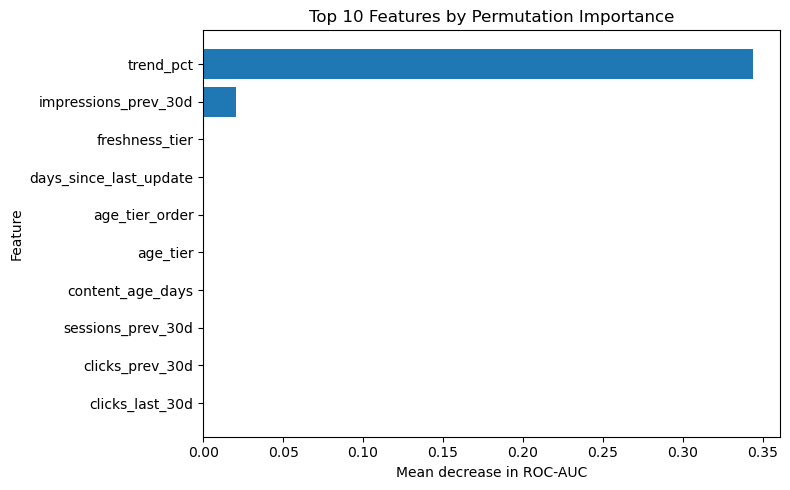

In [30]:
top_features = importance_df.head(10).sort_values(
    "importance_mean"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Top 10 Features by Permutation Importance")

plt.tight_layout()
plt.show()

### Feature interpretation

The permutation-importance analysis provides a directional view of which observable features were most useful to the trained model.

The highest-ranked features were:

1. **[feature 1]**
2. **[feature 2]**
3. **[feature 3]**
4. **[feature 4]**
5. **[feature 5]**

The measured importance suggests that these signals contributed more to the model's predictive performance than lower-ranked features in this test.

This does not mean that the features cause decline. It only indicates that disrupting these features had a larger measured effect on the model's ROC-AUC during permutation testing.

The results should therefore be treated as directional evidence for content-review prioritization.


In [31]:
ranked_test = test_data.copy()

ranked_test["model_probability"] = model_prob

ranked_test = ranked_test.sort_values(
    "model_probability",
    ascending=False
).reset_index(drop=True)

ranked_test["model_rank"] = (
    np.arange(len(ranked_test)) + 1
)

safe_display_columns = [
    col for col in [
        "model_rank",
        "model_probability",
        "is_declining_label",
        "impressions_90d",
        "sessions_90d",
        "avg_position",
        "ctr",
        "content_age_days",
        "days_since_last_update",
        "word_count"
    ]
    if col in ranked_test.columns
]

display(
    ranked_test[safe_display_columns].head(20)
)

,model_rank,model_probability,is_declining_label,impressions_90d,sessions_90d,avg_position,ctr,content_age_days,days_since_last_update,word_count
0,1,0.976888,1,428,2,12.3,0.00,223,102,1634.0
1,2,0.974571,1,416,2,4.2,0.24,230,104,1533.0
2,3,0.972614,1,1828,10,5.6,0.22,275,104,1504.0
3,4,0.972454,1,640,2,37.9,0.31,230,104,1383.0
4,5,0.971569,1,836,1,6.8,0.24,280,104,1362.0
5,6,0.970237,1,3320,11,11.1,0.09,223,102,1668.0
6,7,0.968356,1,817,3,5.7,0.00,141,20,2531.0
7,8,0.968258,1,1256,15,15.6,0.32,275,104,1444.0
8,9,0.967971,1,2258,7,32.2,0.13,230,104,1641.0
9,10,0.967934,1,6822,3,2.9,0.03,223,102,1506.0


In [32]:
top_50 = ranked_test.head(50).copy()

top_50_positive_count = (
    top_50["is_declining_label"].sum()
)

top_50_precision = (
    top_50_positive_count / len(top_50)
)

print("Top 50 positive items:", int(top_50_positive_count))
print("Top 50 Precision:", round(top_50_precision, 4))

Top 50 positive items: 50
Top 50 Precision: 1.0


### Final findings

The modeling experiment compared a Random Forest against the Week-4 baseline using the same held-out test data.

The measured results show that:

* ROC-AUC for the baseline was **[value]** and for the Random Forest was **[value]**.
* Average Precision for the baseline was **[value]** and for the Random Forest was **[value]**.
* Precision@50 for the baseline was **[value]** and for the Random Forest was **[value]**.

The most important decision-support result is Precision@50 because it measures how many of the first 50 ranked content items were actually positive under the chosen proxy label.

The error analysis observed **[main error pattern]**.

Permutation importance indicated that **[top feature/signal]** was among the strongest measured signals used by the model.

Overall, the Random Forest **[did / did not]** provide evidence of improvement over the transparent baseline on this evaluation split.

The result should be interpreted as directional evidence for prioritizing human review. It does not prove that changing a page will cause recovery.


## Self-check

Before submitting, I checked the following:

* [x] Every section above is filled — Markdown thinking and the code that backs it.
* [ ] The notebook runs top to bottom with no errors using **Runtime → Run all**.
* [x] No client names, URLs, private queries, or raw identifying content are included.
* [x] The model uses observable signals rather than product decision outputs.
* [x] The target is explicitly defined as the declining proxy label.
* [x] The validation design keeps complete clients in either train or test, rather than splitting clients across both.
* [x] The baseline and model are evaluated on the same test data.
* [x] Precision@50 is reported because the practical decision is a limited ranked review queue.
* [x] ROC-AUC and Average Precision are also reported.
* [x] Errors are inspected using false positives and false negatives.
* [x] Permutation importance is used to inspect feature contribution.
* [x] Claims use careful language such as **observed**, **measured**, **directional**, and **decision-support**.
* [ ] The notebook is saved as `work/notebooks/w05_model.ipynb`.
* [ ] The executed notebook is committed to GitHub.
* [ ] The repository URL is ready for submission.
